<a href="https://colab.research.google.com/github/walnutta/404_project/blob/main/404groupprj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import sklearn
import re


In [2]:
# file extraction
train_url = "https://raw.githubusercontent.com/EducationalTestingService/sarcasm/master/twitter/sarcasm_detection_shared_task_twitter_training.jsonl"
test_url  = "https://raw.githubusercontent.com/EducationalTestingService/sarcasm/master/twitter/sarcasm_detection_shared_task_twitter_testing.jsonl"

twitter_train_df = pd.read_json(train_url, lines=True)
twitter_test_df  = pd.read_json(test_url, lines=True)

reddit_train_url = "https://raw.githubusercontent.com/EducationalTestingService/sarcasm/master/reddit/sarcasm_detection_shared_task_reddit_training.jsonl"
reddit_test_url  = "https://raw.githubusercontent.com/EducationalTestingService/sarcasm/master/reddit/sarcasm_detection_shared_task_reddit_testing.jsonl"

reddit_train_df = pd.read_json(reddit_train_url, lines=True)
reddit_test_df  = pd.read_json(reddit_test_url,  lines=True)

In [3]:

train_df = pd.concat([twitter_train_df, reddit_train_df], ignore_index=True)
test_df  = pd.concat([twitter_test_df,  reddit_test_df],  ignore_index=True)

# shuffle so twitter and reddit tweets are mixed
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(frac=1,  random_state=42).reset_index(drop=True)

print(f"Combined train: {len(train_df)}")
print(f"Combined test:  {len(test_df)}")

Combined train: 9400
Combined test:  3600


In [4]:
train_df.head()

,label,response,context
0,NOT_SARCASM,The moment she discovers she's the same person...,[From homelessness at young #age as #Refugees ...
1,NOT_SARCASM,@USER @USER @USER Give me nothing . Just sayin...,[@USER @USER @USER A question noone is asking ...
2,NOT_SARCASM,@USER @USER @USER #LastNight ’ s 1st #FullMoon...,"[@USER @USER @USER doesn ’ t know it yet , but..."
3,SARCASM,All that was missing was the neck beard am i r...,"[TIL of Deborah Nadoolman, who was a film and ..."
4,NOT_SARCASM,@USER You love #communism #marxism and #anarch...,[#Trump supporter shows up at Anti - #TrumpPro...


In [5]:
train_df.columns

Index(['label', 'response', 'context'], dtype='object')

In [6]:
def count_sarcastic_emojis(text):
  # emojis strongly associated with sarcasm
  sarcastic_emojis = {'🙄', '😒', '😏', '🤦', '💀', '😐', '🫠', '😑', '👏', '🤷'}
  return sum(1 for char in text if char in sarcastic_emojis)

def clean_text(text):
  text = str(text)
  text = re.sub(r'@USER', '', text)           # remove @USER after counting
  text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
  text = re.sub(r'[^\w\s!?.,\'"]', '', text)  # remove only special chars that I dont think impact the rating
  text = re.sub(r'[^\w\s!?.,\'\"\U00010000-\U0010ffff]', '', text)
  text = re.sub(r'\s+', ' ', text)
  return text.strip()

def process_row(row):
  raw = str(row['response'])

  # reply depth before cleaning
  reply_depth = len(re.findall(r'@USER', raw))

  # clean main tweet and context
  cleaned_response = clean_text(raw)

  if isinstance(row['context'], list):
      context_list = row['context']
  else:
      context_list = []
  context_str = clean_text(' '.join([str(c) for c in context_list]))
  full_text = cleaned_response + ' [CONTEXT] ' + context_str

  # label
  label = 1 if row['label'] == 'SARCASM' else 0

  # expanded features on cleaned text
  words = full_text.split()
  word_count = len(words)

  exclaim_count = full_text.count('!')
  question_count = full_text.count('?')
  period_count = full_text.count('.')
  quote_count = full_text.count('"') + full_text.count("'")
  punct_ratio = (exclaim_count + question_count) / max(word_count, 1)

  all_caps_words = sum(1 for w in words if w.isupper() and len(w) > 1)
  all_caps_ratio = all_caps_words / max(word_count, 1)

  repeated_chars = len(re.findall(r'(.)\1{2,}', full_text))
  avg_word_length = sum(len(w) for w in words) / max(word_count, 1)
  sarcastic_emoji_count = count_sarcastic_emojis(raw)  # on raw before cleaning

  return pd.Series({
    'clean_response':        cleaned_response,
    'full_text':             full_text,

    'reply_depth':           reply_depth,
    'word_count':            word_count,
    'avg_word_length':       avg_word_length,
    'exclaim_count':         exclaim_count,
    'question_count':        question_count,
    'period_count':          period_count,
    'quote_count':           quote_count,
    'punct_ratio':           punct_ratio,
    'all_caps_count':        all_caps_words,
    'all_caps_ratio':        all_caps_ratio,
    'repeated_chars':        repeated_chars,
    'sarcastic_emoji_count': sarcastic_emoji_count,
    'label':                 label
  })

train_clean = train_df.apply(process_row, axis=1)
test_clean  = test_df.apply(process_row, axis=1)

train_clean = train_df.apply(process_row, axis=1)
test_clean  = test_df.apply(process_row, axis=1)

train_clean.head()

,clean_response,full_text,reply_depth,word_count,avg_word_length,exclaim_count,question_count,period_count,quote_count,punct_ratio,all_caps_count,all_caps_ratio,repeated_chars,sarcastic_emoji_count,label
0,The moment she discovers she's the same person...,The moment she discovers she's the same person...,3,117,4.452991,0,0,2,1,0.000000,6,0.051282,0,0,0
1,Give me nothing . Just saying no one really kn...,Give me nothing . Just saying no one really kn...,3,751,3.872170,11,10,47,27,0.027963,23,0.030626,3,0,0
2,"LastNight s 1st FullMoon of 2020 ! as always ,...","LastNight s 1st FullMoon of 2020 ! as always ,...",3,314,3.729299,18,5,22,0,0.073248,22,0.070064,4,0,0
3,All that was missing was the neck beard am i r...,All that was missing was the neck beard am i r...,0,69,4.695652,0,1,2,4,0.014493,2,0.028986,0,0,1
4,You love communism marxism and anarchy and eve...,You love communism marxism and anarchy and eve...,1,161,4.521739,1,4,13,6,0.031056,8,0.049689,1,0,0


In [22]:
# fit training data, then transform both
vectorizer = TfidfVectorizer(
  ngram_range=(1, 4),
  max_features=20000,   # top most important terms
  sublinear_tf=True     # repeated words have less weight
)

X_train_tfidf = vectorizer.fit_transform(train_clean["full_text"])
X_test_tfidf = vectorizer.transform(test_clean["full_text"])

# stacking the features singled out manually above with output of tf-idf to use as our final data format
feature_cols = [
    'reply_depth', 'word_count', 'avg_word_length',
    'exclaim_count', 'question_count', 'period_count',
    'quote_count', 'punct_ratio', 'all_caps_count',
    'all_caps_ratio', 'repeated_chars', 'sarcastic_emoji_count'
]

extra_train = train_clean[feature_cols].values
extra_test  = test_clean[feature_cols].values

X_train = hstack([X_train_tfidf, extra_train])
X_test  = hstack([X_test_tfidf, extra_test])
y_train = train_clean["label"]
y_test  = test_clean["label"]

              precision    recall  f1-score   support

 Not Sarcasm       0.61      0.61      0.61      1800
     Sarcasm       0.61      0.61      0.61      1800

    accuracy                           0.61      3600
   macro avg       0.61      0.61      0.61      3600
weighted avg       0.61      0.61      0.61      3600



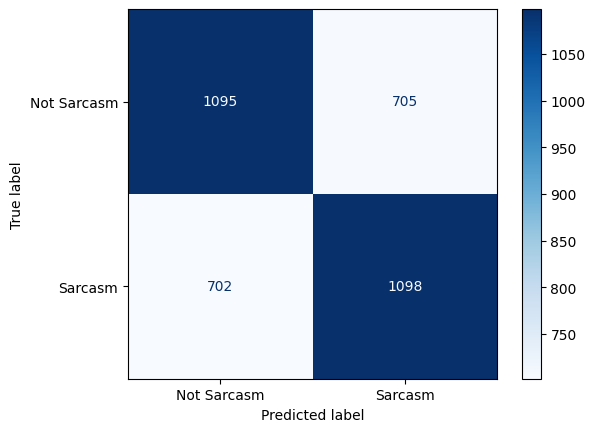

In [23]:
model = LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear", C=2)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Not Sarcasm", "Sarcasm"]))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Sarcasm", "Sarcasm"]).plot(cmap="Blues")

# RNN

In [10]:
!wget http://nlp.stanford.edu/data/glove.twitter.27B.zip -q --show-progress
!unzip glove.twitter.27B.zip glove.twitter.27B.100d.txt

glove.twitter.27B.z 100%[===================>]   1.42G  5.02MB/s    in 4m 46s  
Archive:  glove.twitter.27B.zip
  inflating: glove.twitter.27B.100d.txt  


In [11]:
import tensorflow as tf
from tensorflow import keras  #ignore this red line
from tf_keras.preprocessing.text import Tokenizer
from tf_keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from keras.callbacks import EarlyStopping

In [12]:
glove_embeddings = {}
with open("glove.twitter.27B.100d.txt", encoding='utf-8') as f:
  for line in f:
    values = line.split()
    word   = values[0]
    vector = np.array(values[1:], dtype="float32")
    glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings)} word vectors")

Loaded 1193514 word vectors


In [13]:
# Check distribution to choose appropriate max length
lengths = train_clean["full_text"].apply(lambda x: len(x.split()))
print(f"95th percentile length: {np.percentile(lengths, 95)}")
print(f"99th percentile length: {np.percentile(lengths, 99)}")

95th percentile length: 243.0
99th percentile length: 451.03000000000065


In [25]:
MAX_VOCAB = 20000
MAX_LEN = int(np.percentile(lengths, 95))

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_clean["full_text"])

X_train_seq = tokenizer.texts_to_sequences(train_clean["full_text"])
X_test_seq  = tokenizer.texts_to_sequences(test_clean["full_text"])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

y_train = train_clean["label"].values
y_test  = test_clean["label"].values

print(f"Train shape: {X_train_pad.shape}")
print(f"Test shape:  {X_test_pad.shape}")


EMBEDDING_DIM    = 100
embedding_matrix = np.zeros((MAX_VOCAB, EMBEDDING_DIM))

for word, idx in tokenizer.word_index.items():
  if idx < MAX_VOCAB:
    vector = glove_embeddings.get(word)
    if vector is not None:
      embedding_matrix[idx] = vector

print(f"Embedding matrix shape: {embedding_matrix.shape}")

#######################################################
model = Sequential([
Embedding(
    input_dim = MAX_VOCAB,
    output_dim = EMBEDDING_DIM,
    weights = [embedding_matrix],
    input_length = MAX_LEN,
    trainable = False
  ),
  Bidirectional(LSTM(128)),
  Dropout(0.4),
  Dense(32, activation="relu"),
  Dropout(0.3),
  Dense(1, activation="sigmoid")
])
##########################################################
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
              loss="binary_crossentropy",    # without this it can't calculate error
              metrics=["accuracy"])
model.summary()

# earlystop apply because data is overfitting early at this point
early_stop = EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True,verbose=1)

history = model.fit( X_train_pad, y_train, epochs=20, batch_size=100, validation_split=0.1, callbacks=[early_stop])

Train shape: (9400, 243)
Test shape:  (3600, 243)
Embedding matrix shape: (20000, 100)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 76s 848ms/step - accuracy: 0.5358 - loss: 0.6873 - val_accuracy: 0.6394 - val_loss: 0.6090
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 71s 833ms/step - accuracy: 0.6347 - loss: 0.6280 - val_accuracy: 0.6404 - val_loss: 0.6044
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 73s 861ms/step - accuracy: 0.6337 - loss: 0.6203 - val_accuracy: 0.6457 - val_loss: 0.6034
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 87s 923ms/step - accuracy: 0.6457 - loss: 0.6089 - val_accuracy: 0.6638 - val_loss: 0.5973
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 74s 873ms/step - accuracy: 0.6595 - loss: 0.6019 - val_accuracy: 0.6564 - val_loss: 0.5967
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 71s 837ms/step - accuracy: 0.6705 - loss: 0.5883 - val_accuracy: 0.6638 - val_loss: 0.5959
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 71s 834ms/step - accuracy: 0.6779 - loss: 0.5827 - val_accuracy: 0.6638 - val_loss: 0.5971
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 72s 849ms/step - accuracy: 0.6754 - loss: 0.5827 - val_accu

113/113 ━━━━━━━━━━━━━━━━━━━━ 21s 186ms/step
              precision    recall  f1-score   support

 Not Sarcasm       0.63      0.67      0.65      1800
     Sarcasm       0.65      0.61      0.63      1800

    accuracy                           0.64      3600
   macro avg       0.64      0.64      0.64      3600
weighted avg       0.64      0.64      0.64      3600



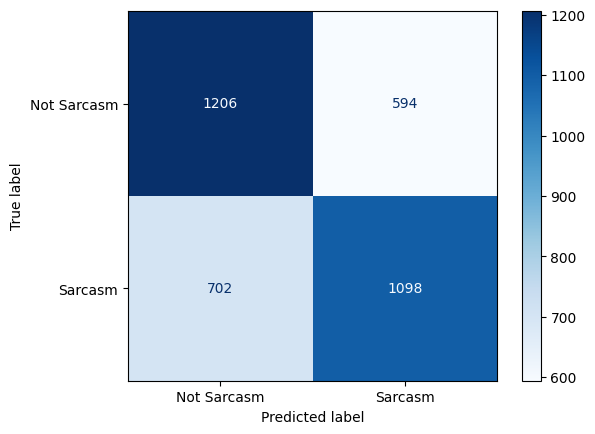

In [26]:
y_pred_prob = model.predict(X_test_pad)
y_pred_rnn = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred_rnn, target_names=["Not Sarcasm", "Sarcasm"]))

cm = confusion_matrix(y_test, y_pred_rnn)
ConfusionMatrixDisplay(cm, display_labels=["Not Sarcasm", "Sarcasm"]).plot(cmap="Blues")